In [1]:
from matplotlib import pyplot as plt
from matplotlib import colors
import numpy as np
from matplotlib.patches import Path, PathPatch
import pandas as pd
from shapely.geometry import Point, shape, Polygon
from shapely.ops import unary_union, cascaded_union
from geopandas.tools import sjoin
import geopandas as gpd
from netCDF4 import Dataset
from cartopy import crs as ccrs
from cartopy.io.shapereader import Reader
from sklearn.metrics import mean_squared_error
import scipy.stats as st
from sklearn.linear_model import LinearRegression
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.ticker import FormatStrFormatter
import matplotlib.pyplot as plt
import numpy as np
import re import matplotlib.patheffects as pe
import cartopy.crs as ccrs

C:\Users\x12la\AppData\Local\Temp\ipykernel_30060\3062881070.py:8: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  from geopandas.tools import sjoin


In [2]:
# CMAQ lat/lon datafile
d03 = Dataset('C:/Users/x12la/Desktop/latlon_ChicagoLADCO_d03.nc')
cmaq_lon,cmaq_lat = np.array(d03['lon']),np.array(d03['lat'])
cmaq_llat,cmaq_ulat,cmaq_llon,cmaq_ulon=cmaq_lat.min(), cmaq_lat.max(), cmaq_lon.min(), cmaq_lon.max()

In [3]:
#CMAP 7 counties surrounding Chicago/Cook County
cmap_cty = gpd.read_file('C:/Users/x12la/Desktop/Scripts/CMAP_cty.shp')
cmap_cty = cmap_cty.to_crs('EPSG:4326')

#primary roads
primary_roads = gpd.read_file('C:/Users/x12la/Desktop/Scripts/tl_2016_us_primaryroads.shp')
primary_roads = primary_roads.to_crs('EPSG:4326')

In [4]:
base_aconc = gpd.read_file("COMBINE_ACONC_BASE_2023_annual.shp").to_crs("EPSG:4326")
base_o3    = gpd.read_file("dailymaxozone_base_2023_annual.shp").to_crs("EPSG:4326")
locus_aconc = gpd.read_file("COMBINE_ACONC_LOCUSIdling_HDVSpatial_2023_annual.shp").to_crs("EPSG:4326")
locus_o3    = gpd.read_file("dailymaxozone_LOCUSIdling_HDVSpatial_2023_annual.shp").to_crs("EPSG:4326")

In [29]:
fourhighestozonedays = gpd.read_file("four_highest_CMAP_dailymean_MDA8O3_BASE_LOCUS.shp").to_crs("EPSG:4326")

In [30]:
cmap_domain = cmap_cty.geometry.unary_union
cmap_roads = gpd.clip(primary_roads, cmap_domain)
cmap_roads = cmap_roads[cmap_roads.geometry.geom_type.isin(["LineString", "MultiLineString"])].copy()

cmap_fourhighestdays = gpd.clip(fourhighestozonedays, cmap_domain)
cmap_base_aconc  = gpd.clip(base_aconc, cmap_domain)
cmap_base_o3     = gpd.clip(base_o3, cmap_domain)
cmap_locus_aconc = gpd.clip(locus_aconc, cmap_domain)
cmap_locus_o3    = gpd.clip(locus_o3, cmap_domain)

<h1> Plot Differences EPA Default and LOCUS + HDV On-road Mod

C:\Users\x12la\AppData\Local\Temp\ipykernel_30060\2720921469.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_disc = ListedColormap(plt.cm.get_cmap(cfg["cmap_name"])(np.linspace(0, 1, N_BINS)))
C:\Users\x12la\AppData\Local\Temp\ipykernel_30060\2720921469.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  diff_cmap = ListedColormap(plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS)))
C:\Users\x12la\AppData\Local\Temp\ipykernel_30060\2720921469.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps

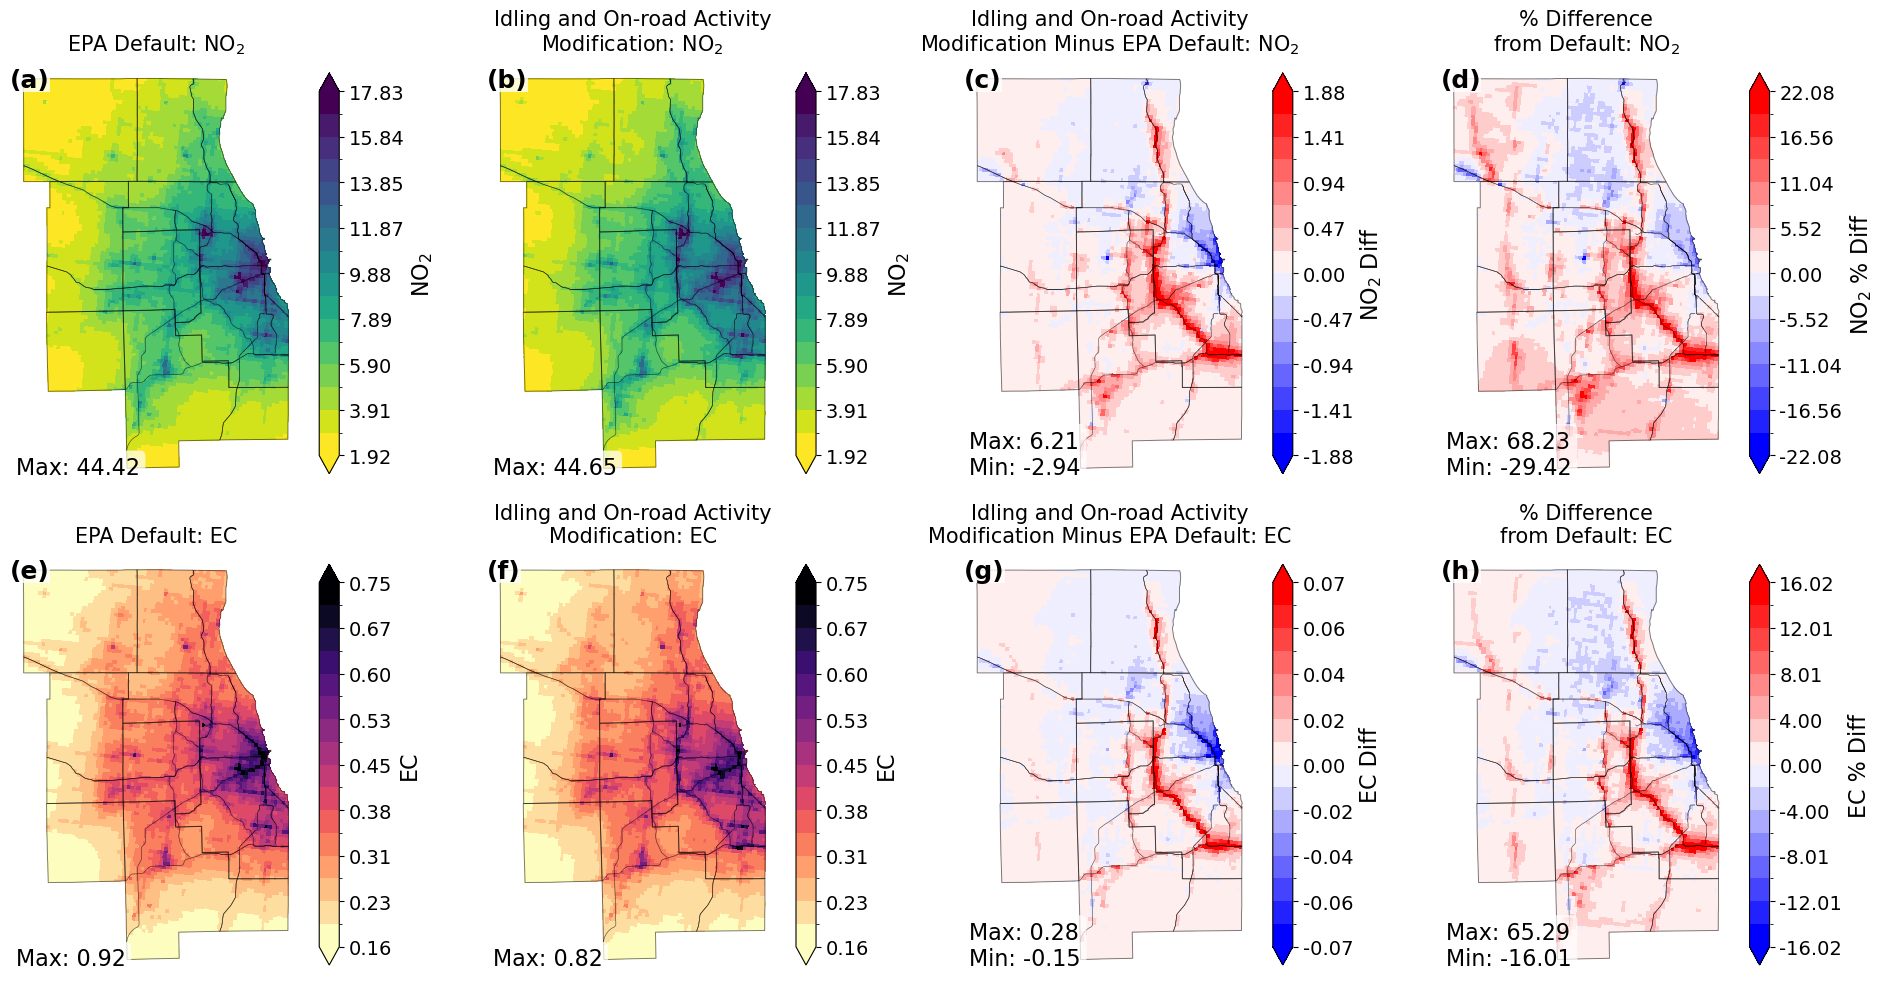

In [37]:
# plotting setup
N_BINS = 16
pollutants = ["NO2", "PM25_EC"]
scenario_names = ["EPA Default", "Idling and On-road Activity\nModification", "Idling and On-road Activity\nModification Minus EPA Default", "% Difference\nfrom Default"]

plot_config = {"NO2": {"cmap_name": "viridis_r", "title": "NO$_2$", "label": "NO$_2$", "column": "NO2"}, "PM25_EC": {"cmap_name": "magma_r", "title": "EC", "label": "EC", "column": "PM25_EC"}}
annual_gdfs_by_pol = {"NO2": {"reference": cmap_base_aconc, "scenario": cmap_locus_aconc}, "PM25_EC": {"reference": cmap_base_aconc, "scenario": cmap_locus_aconc}}

def plot_annual_default_locus():

    # define plotting ranges and discrete colormaps for each pollutant
    abs_styles = {}
    diff_styles = {}

    for pol in pollutants:
        cfg = plot_config[pol]
        col = cfg["column"]
        reference_gdf = annual_gdfs_by_pol[pol]["reference"]
        scenario_gdf = annual_gdfs_by_pol[pol]["scenario"]

        # use nearly the full concentration range while limiting extreme outliers
        vals_all = np.concatenate([gdf[col].astype(float).to_numpy()[np.isfinite(gdf[col].astype(float).to_numpy())] for gdf in [reference_gdf, scenario_gdf]])
        vmin = np.quantile(vals_all, 0.001)
        vmax = np.quantile(vals_all, 0.999)
        if np.isclose(vmin, vmax): vmax = vmin + 1e-6

        cmap_disc = ListedColormap(plt.cm.get_cmap(cfg["cmap_name"])(np.linspace(0, 1, N_BINS)))
        bounds = np.linspace(vmin, vmax, N_BINS + 1)
        abs_styles[pol] = {"bounds": bounds, "cmap": cmap_disc, "norm": BoundaryNorm(bounds, cmap_disc.N)}

        # calculate chage from EPA Default and set symmetric ranges around zero
        reference_vals = reference_gdf[col].astype(float).to_numpy()
        scenario_vals = scenario_gdf[col].astype(float).to_numpy()
        diff_vals = scenario_vals - reference_vals
        pct_vals = np.where(reference_vals != 0, (diff_vals / reference_vals) * 100.0, np.nan)

        diff_lim = np.quantile(np.abs(diff_vals[np.isfinite(diff_vals)]), 0.99)
        pct_lim = np.quantile(np.abs(pct_vals[np.isfinite(pct_vals)]), 0.99)
        if np.isclose(diff_lim, 0): diff_lim = 1e-6
        if np.isclose(pct_lim, 0): pct_lim = 1e-6

        diff_bounds = np.linspace(-diff_lim, diff_lim, N_BINS + 1)
        pct_bounds = np.linspace(-pct_lim, pct_lim, N_BINS + 1)
        diff_cmap = ListedColormap(plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS)))
        pct_cmap = ListedColormap(plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS)))

        diff_styles[pol] = {"diff_bounds": diff_bounds, "diff_cmap": diff_cmap, "diff_norm": BoundaryNorm(diff_bounds, diff_cmap.N), "pct_bounds": pct_bounds, "pct_cmap": pct_cmap, "pct_norm": BoundaryNorm(pct_bounds, pct_cmap.N)}

    # build GeoDataFrames for EPA Default, modified activity, absolute difference, and percent difference
    scenario_gdfs_by_pol = {}

    for pol in pollutants:
        col = plot_config[pol]["column"]
        reference_gdf = annual_gdfs_by_pol[pol]["reference"]
        scenario_gdf = annual_gdfs_by_pol[pol]["scenario"]
        ref_vals = reference_gdf[col].astype(float)
        scen_vals = scenario_gdf[col].astype(float)

        plot_reference = reference_gdf.copy()
        plot_scenario = scenario_gdf.copy()
        plot_diff = scenario_gdf.copy()
        plot_pct = scenario_gdf.copy()

        plot_reference[pol] = ref_vals
        plot_scenario[pol] = scen_vals
        plot_diff[pol] = scen_vals - ref_vals
        plot_pct[pol] = np.where(ref_vals != 0, ((scen_vals - ref_vals) / ref_vals) * 100.0, np.nan)

        scenario_gdfs_by_pol[pol] = {scenario_names[0]: plot_reference, scenario_names[1]: plot_scenario, scenario_names[2]: plot_diff, scenario_names[3]: plot_pct}

    # create 2 x 4 figure for NO2 and EC
    fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(20, 10), subplot_kw={"projection": ccrs.PlateCarree()})

    # plot EPA Default, modified activity, difference, and percent difference
    for i, pol in enumerate(pollutants):
        for j, scen in enumerate(scenario_names):
            ax = axs[i, j]
            gdf = scenario_gdfs_by_pol[pol][scen]
            panel_label = f"({chr(97 + i * 4 + j)})"

            # add panel label
            ax.text(0.001, 0.98, panel_label, transform=ax.transAxes, ha="left", va="top", fontsize=18, fontweight="bold", bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=0.2), zorder=10)

            # select plotting style based on whether the panel shows concentration or change
            if j in [0, 1]:
                cmap_disc, norm, bounds = abs_styles[pol]["cmap"], abs_styles[pol]["norm"], abs_styles[pol]["bounds"]
            elif j == 2:
                cmap_disc, norm, bounds = diff_styles[pol]["diff_cmap"], diff_styles[pol]["diff_norm"], diff_styles[pol]["diff_bounds"]
            else:
                cmap_disc, norm, bounds = diff_styles[pol]["pct_cmap"], diff_styles[pol]["pct_norm"], diff_styles[pol]["pct_bounds"]

            # plot concentrations and geographic reference layers
            gdf.plot(column=pol, ax=ax, cmap=cmap_disc, norm=norm, edgecolor="none", antialiased=False)
            cmap_cty.boundary.plot(ax=ax, color="k", alpha=0.5, linewidth=0.7)
            cmap_roads.plot(ax=ax, color="k", alpha=0.4, linewidth=0.4)
            ax.set_title(f"{scen}: {plot_config[pol]['title']}", fontsize=15)
            ax.set_axis_off()

            # add panel-specific colorbar
            sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_disc)
            sm._A = []
            cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04, boundaries=bounds, ticks=bounds[::2], spacing="proportional", extend="both")
            cbar.ax.tick_params(labelsize=14)
            cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

            if j == 3: cbar.set_label(f"{plot_config[pol]['label']} % Diff", fontsize=16)
            elif j == 2: cbar.set_label(f"{plot_config[pol]['label']} Diff", fontsize=16)
            else: cbar.set_label(plot_config[pol]["label"], fontsize=16)

            # annotate maxima for absolute concentrations and min/max for changes
            vals = gdf[pol].astype(float).to_numpy()
            vals = vals[np.isfinite(vals)]
            vmax_panel = float(np.nanmax(vals))
            vmin_panel = float(np.nanmin(vals))
            annot_text = f"Max: {vmax_panel:.2f}" if j in [0, 1] else f"Max: {vmax_panel:.2f}\nMin: {vmin_panel:.2f}"
            ax.text(0.02, 0.02, annot_text, transform=ax.transAxes, ha="left", va="bottom", fontsize=16, color="black", bbox=dict(facecolor="white", alpha=0.7, boxstyle="round,pad=0.25", linewidth=0), zorder=10)

    # finish layout and save both PNG and PDF (higher qual)
    plt.tight_layout()
    plt.savefig("Fig2_Annualized_Default_MOD_NO2_EC_2023.png", dpi=500, bbox_inches="tight")
    plt.savefig("Fig2_Annualized_Default_MOD_NO2_EC_2023.pdf", dpi=500, bbox_inches="tight")
    plt.show()


plot_annual_default_locus()

In [38]:
# separate primary roads by Census road type in case they are needed for additional map context
cmap_roads_I = cmap_roads.loc[cmap_roads["RTTYP"] == "I"].copy()
cmap_roads_S = cmap_roads.loc[cmap_roads["RTTYP"] == "S"].copy()
cmap_roads_M = cmap_roads.loc[cmap_roads["RTTYP"] == "M"].copy()
cmap_roads_O = cmap_roads.loc[cmap_roads["RTTYP"] == "O"].copy()

# major interstates shown on the map
major_interstates_map = [55, 80, 90, 94, 294]

import matplotlib.patheffects as pe

# manually place sparse interstate labels so they remain readable and do not crowd the figure
def add_interstate_labels_manual(ax, fontsize=12):
    labels = {"I-55": (-87.80, 41.76), "I-80": (-88.10, 41.50), "I-90": (-88.05, 42.02), "I-94": (-87.72, 42.08), "I-294": (-87.92, 41.90)}

    # add a white outline behind each label so it remains visible over mapped concentrations
    for label, (x, y) in labels.items():
        ax.text(x, y, label, fontsize=fontsize, fontweight="bold", ha="center", va="center", color="dimgray", zorder=50, path_effects=[pe.Stroke(linewidth=2.5, foreground="white"), pe.Normal()])

C:\Users\x12la\AppData\Local\Temp\ipykernel_30060\807551753.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_disc = ListedColormap(plt.cm.get_cmap(cfg["cmap_name"])(np.linspace(0, 1, N_BINS)))
C:\Users\x12la\AppData\Local\Temp\ipykernel_30060\807551753.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  diff_cmap = ListedColormap(plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS)))
C:\Users\x12la\AppData\Local\Temp\ipykernel_30060\807551753.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.ge

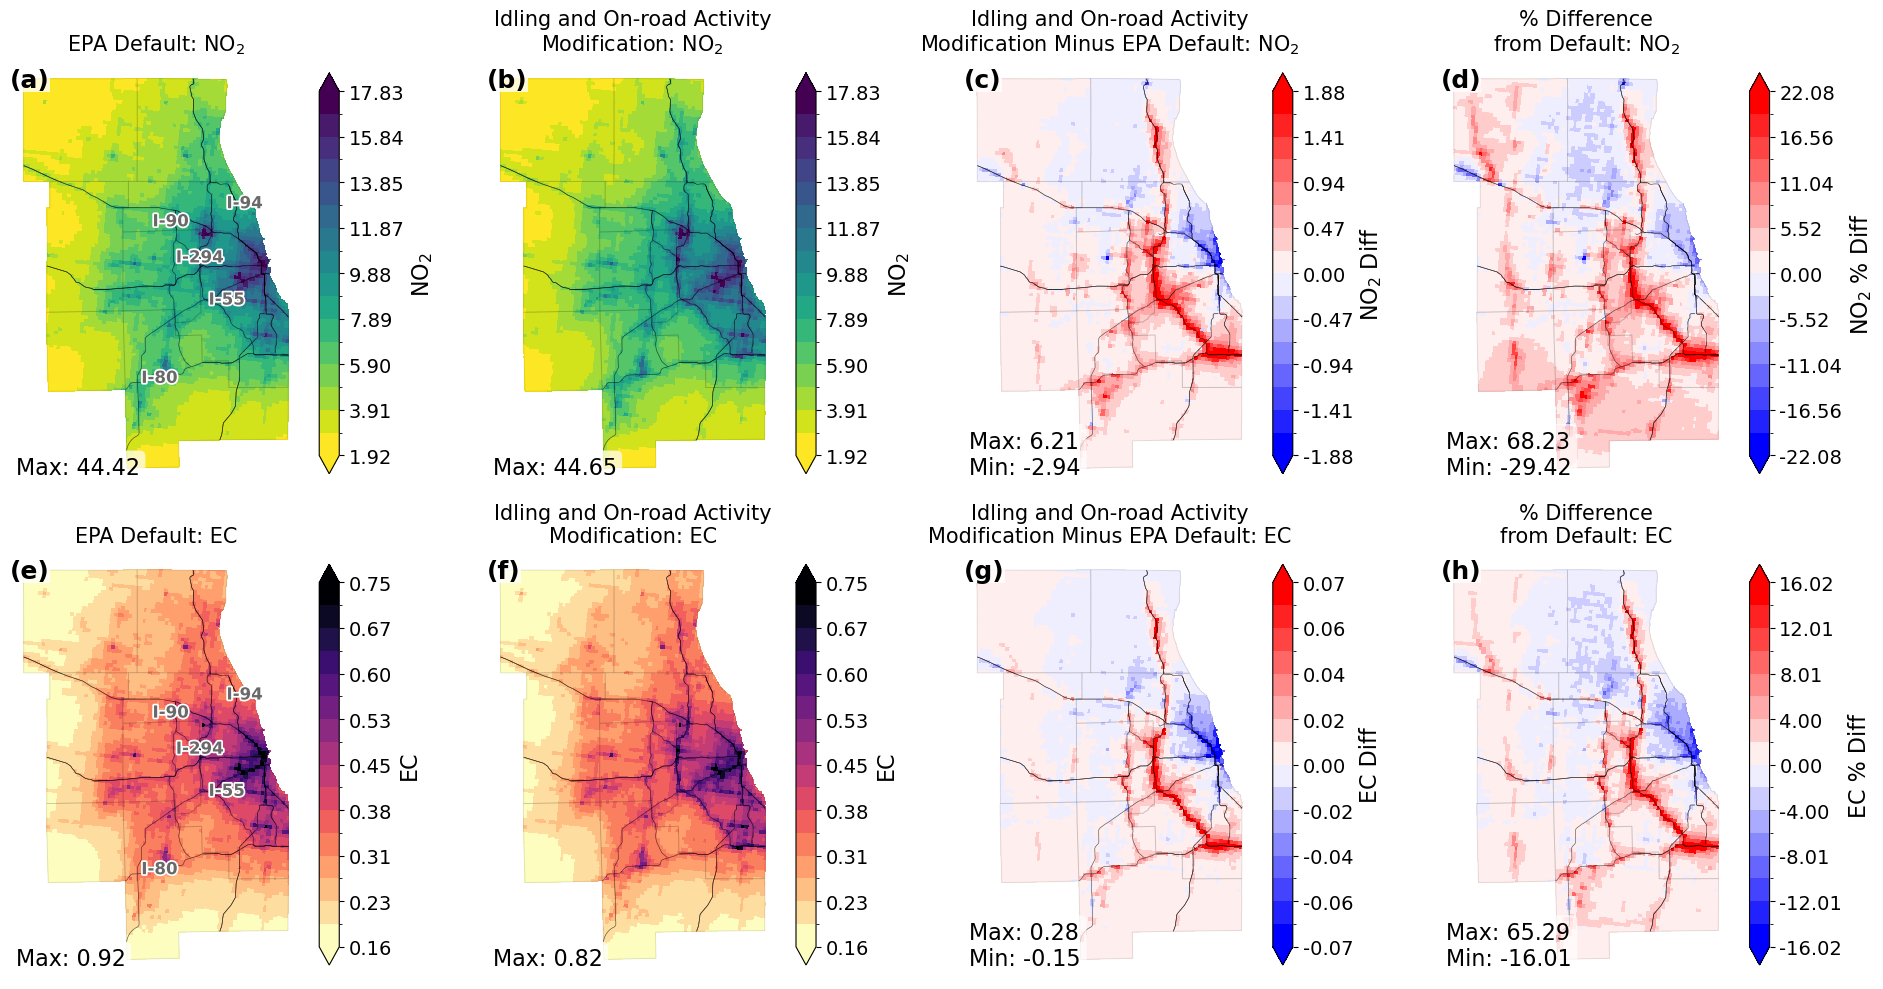

In [45]:
# plotting setup
N_BINS = 16
pollutants = ["NO2", "PM25_EC"]
scenario_names = ["EPA Default", "Idling and On-road Activity\nModification", "Idling and On-road Activity\nModification Minus EPA Default", "% Difference\nfrom Default"]

plot_config = {"NO2": {"cmap_name": "viridis_r", "title": "NO$_2$", "label": "NO$_2$", "column": "NO2"}, "PM25_EC": {"cmap_name": "magma_r", "title": "EC", "label": "EC", "column": "PM25_EC"}}
annual_gdfs_by_pol = {"NO2": {"reference": cmap_base_aconc, "scenario": cmap_locus_aconc}, "PM25_EC": {"reference": cmap_base_aconc, "scenario": cmap_locus_aconc}}


def plot_annual_default_locus():

    # set shared plotting ranges and colormaps for each pollutant
    abs_styles = {}
    diff_styles = {}

    for pol in pollutants:
        cfg = plot_config[pol]
        col = cfg["column"]
        reference_gdf = annual_gdfs_by_pol[pol]["reference"]
        scenario_gdf = annual_gdfs_by_pol[pol]["scenario"]

        # use the same absolute concentration range for EPA Default and the modified activity scenario
        vals_all = np.concatenate([gdf[col].astype(float).to_numpy()[np.isfinite(gdf[col].astype(float).to_numpy())] for gdf in [reference_gdf, scenario_gdf]])
        vmin = np.quantile(vals_all, 0.001)
        vmax = np.quantile(vals_all, 0.999)
        if np.isclose(vmin, vmax): vmax = vmin + 1e-6

        cmap_disc = ListedColormap(plt.cm.get_cmap(cfg["cmap_name"])(np.linspace(0, 1, N_BINS)))
        bounds = np.linspace(vmin, vmax, N_BINS + 1)
        abs_styles[pol] = {"bounds": bounds, "cmap": cmap_disc, "norm": BoundaryNorm(bounds, cmap_disc.N)}

        # calculate absolute and percent changes from EPA Default and center both scales on zero
        reference_vals = reference_gdf[col].astype(float).to_numpy()
        scenario_vals = scenario_gdf[col].astype(float).to_numpy()
        diff_vals = scenario_vals - reference_vals
        pct_vals = np.where(reference_vals != 0, (diff_vals / reference_vals) * 100.0, np.nan)

        diff_lim = np.quantile(np.abs(diff_vals[np.isfinite(diff_vals)]), 0.99)
        pct_lim = np.quantile(np.abs(pct_vals[np.isfinite(pct_vals)]), 0.99)
        if np.isclose(diff_lim, 0): diff_lim = 1e-6
        if np.isclose(pct_lim, 0): pct_lim = 1e-6

        diff_bounds = np.linspace(-diff_lim, diff_lim, N_BINS + 1)
        pct_bounds = np.linspace(-pct_lim, pct_lim, N_BINS + 1)
        diff_cmap = ListedColormap(plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS)))
        pct_cmap = ListedColormap(plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS)))
        diff_styles[pol] = {"diff_bounds": diff_bounds, "diff_cmap": diff_cmap, "diff_norm": BoundaryNorm(diff_bounds, diff_cmap.N), "pct_bounds": pct_bounds, "pct_cmap": pct_cmap, "pct_norm": BoundaryNorm(pct_bounds, pct_cmap.N)}

    # create plotting GeoDataFrames for EPA Default, modified activity, absolute difference, and percent difference
    scenario_gdfs_by_pol = {}

    for pol in pollutants:
        col = plot_config[pol]["column"]
        reference_gdf = annual_gdfs_by_pol[pol]["reference"]
        scenario_gdf = annual_gdfs_by_pol[pol]["scenario"]
        ref_vals = reference_gdf[col].astype(float)
        scen_vals = scenario_gdf[col].astype(float)

        plot_reference = reference_gdf.copy()
        plot_scenario = scenario_gdf.copy()
        plot_diff = scenario_gdf.copy()
        plot_pct = scenario_gdf.copy()

        plot_reference[pol] = ref_vals
        plot_scenario[pol] = scen_vals
        plot_diff[pol] = scen_vals - ref_vals
        plot_pct[pol] = np.where(ref_vals != 0, ((scen_vals - ref_vals) / ref_vals) * 100.0, np.nan)
        scenario_gdfs_by_pol[pol] = {scenario_names[0]: plot_reference, scenario_names[1]: plot_scenario, scenario_names[2]: plot_diff, scenario_names[3]: plot_pct}

    # create 2 x 4 figure for NO2 and EC
    fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(20, 10), subplot_kw={"projection": ccrs.PlateCarree()})

    # plot each pollutant across EPA Default, modified activity, difference, and percent difference
    for i, pol in enumerate(pollutants):
        for j, scen in enumerate(scenario_names):
            ax = axs[i, j]
            gdf = scenario_gdfs_by_pol[pol][scen]
            panel_label = f"({chr(97 + i * 4 + j)})"

            # add panel label
            ax.text(0.001, 0.98, panel_label, transform=ax.transAxes, ha="left", va="top", fontsize=18, fontweight="bold", bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=0.2), zorder=10)

            # select absolute, difference, or percent-difference plotting style
            if j in [0, 1]: cmap_disc, norm, bounds = abs_styles[pol]["cmap"], abs_styles[pol]["norm"], abs_styles[pol]["bounds"]
            elif j == 2: cmap_disc, norm, bounds = diff_styles[pol]["diff_cmap"], diff_styles[pol]["diff_norm"], diff_styles[pol]["diff_bounds"]
            else: cmap_disc, norm, bounds = diff_styles[pol]["pct_cmap"], diff_styles[pol]["pct_norm"], diff_styles[pol]["pct_bounds"]

            # plot concentrations and geographic reference layers
            gdf.plot(column=pol, ax=ax, cmap=cmap_disc, norm=norm, edgecolor="none", antialiased=False)
            cmap_cty.boundary.plot(ax=ax, color="k", alpha=0.1, linewidth=0.7)
            cmap_roads.plot(ax=ax, color="k", alpha=0.4, linewidth=0.4)

            # label major interstates only on the first panel in each row
            if j == 0: add_interstate_labels_manual(ax, fontsize=12)

            ax.set_title(f"{scen}: {plot_config[pol]['title']}", fontsize=15)
            ax.set_axis_off()

            # add panel-specific colorbar
            sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_disc)
            sm._A = []
            cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04, boundaries=bounds, ticks=bounds[::2], spacing="proportional", extend="both")
            cbar.ax.tick_params(labelsize=14)
            cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

            if j == 3: cbar.set_label(f"{plot_config[pol]['label']} % Diff", fontsize=16)
            elif j == 2: cbar.set_label(f"{plot_config[pol]['label']} Diff", fontsize=16)
            else: cbar.set_label(plot_config[pol]["label"], fontsize=16)

            # show only the maximum for concentration panels and both extremes for difference panels
            vals = gdf[pol].astype(float).to_numpy()
            vals = vals[np.isfinite(vals)]
            vmax_panel = float(np.nanmax(vals))
            vmin_panel = float(np.nanmin(vals))
            annot_text = f"Max: {vmax_panel:.2f}" if j in [0, 1] else f"Max: {vmax_panel:.2f}\nMin: {vmin_panel:.2f}"
            ax.text(0.02, 0.02, annot_text, transform=ax.transAxes, ha="left", va="bottom", fontsize=16, color="black", bbox=dict(facecolor="white", alpha=0.7, boxstyle="round,pad=0.25", linewidth=0), zorder=10)

    # finish layout and save as both PNG and PDF
    plt.tight_layout()
    plt.savefig("Fig3_Annualized_Default_MOD_NO2_EC_2023_withroads.png", dpi=500, bbox_inches="tight")
    plt.savefig("Fig3_Annualized_Default_MOD_NO2_EC_2023_withroadss.pdf", dpi=500, bbox_inches="tight")
    plt.show()


plot_annual_default_locus()

C:\Users\x12la\AppData\Local\Temp\ipykernel_30060\1171082097.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_disc = ListedColormap(plt.cm.get_cmap(cfg["cmap_name"])(np.linspace(0, 1, N_BINS)))
C:\Users\x12la\AppData\Local\Temp\ipykernel_30060\1171082097.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  diff_cmap = ListedColormap(plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS)))
C:\Users\x12la\AppData\Local\Temp\ipykernel_30060\1171082097.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps

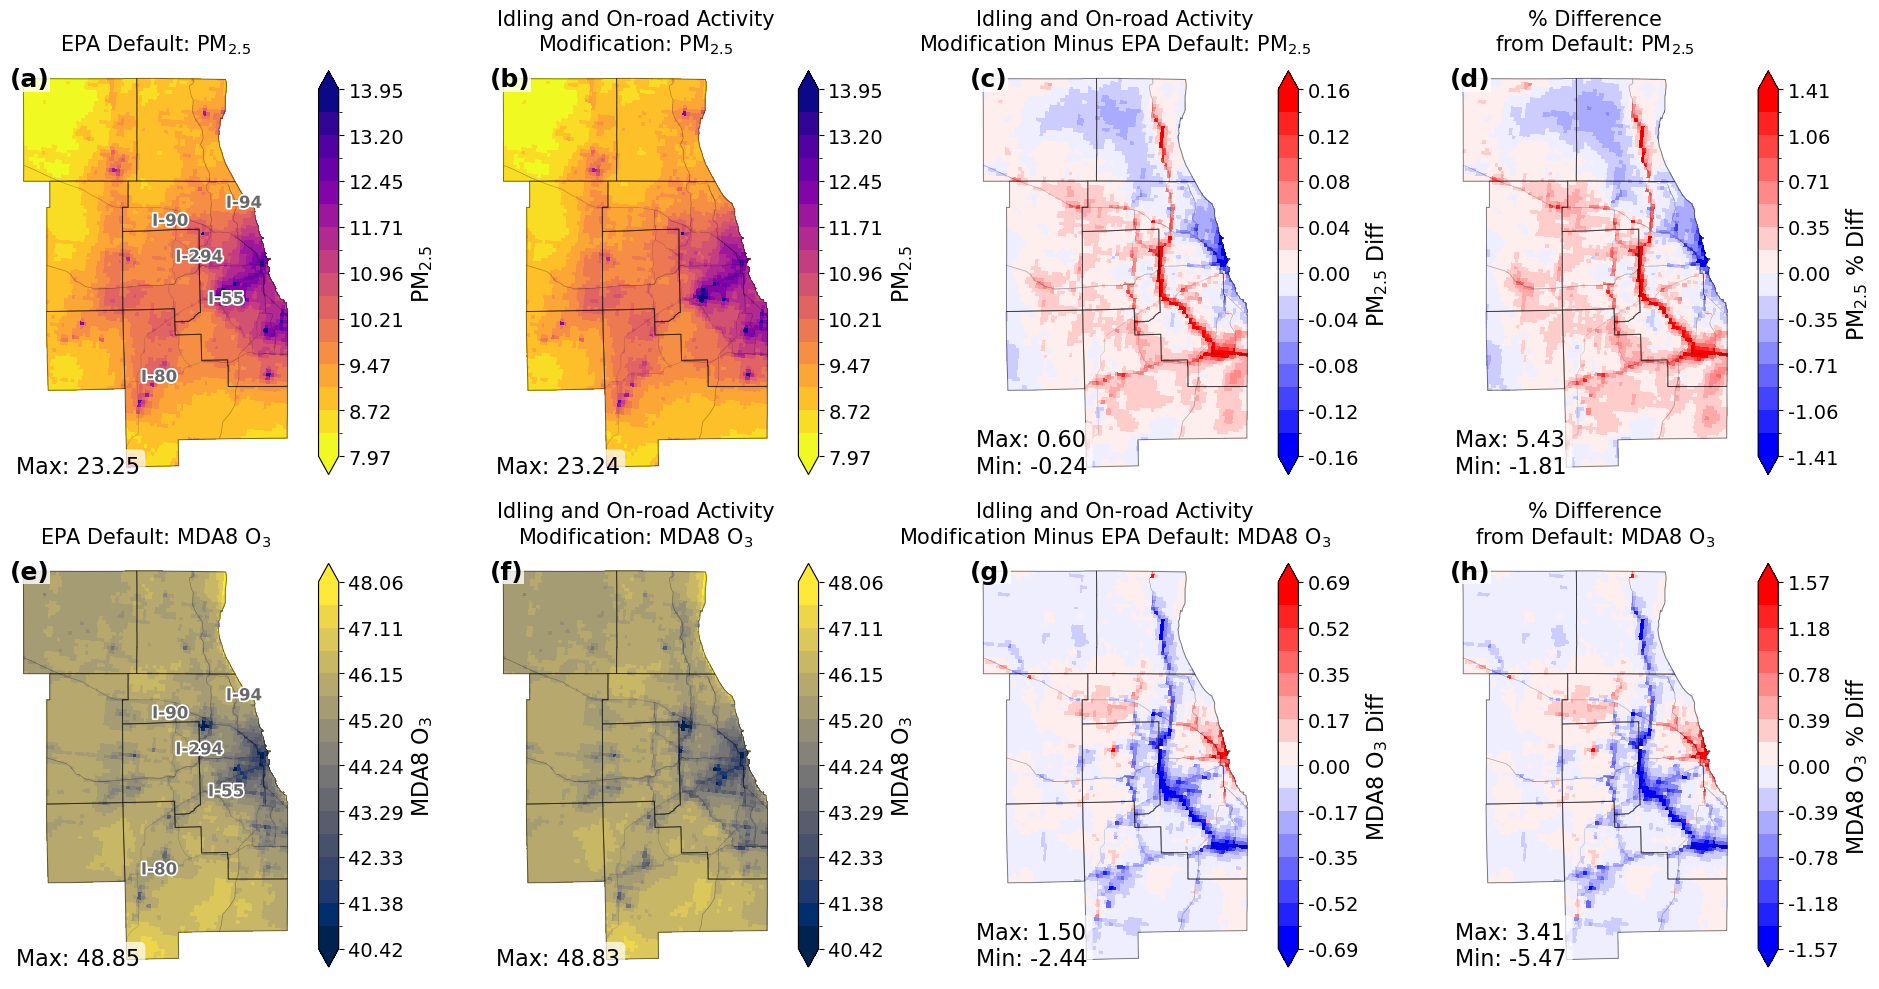

In [44]:
# plotting setup
N_BINS = 16
pollutants = ["PM25_TOT", "O3"]
scenario_names = ["EPA Default", "Idling and On-road Activity\nModification", "Idling and On-road Activity\nModification Minus EPA Default", "% Difference\nfrom Default"]

plot_config = {"PM25_TOT": {"cmap_name": "plasma_r", "title": "PM$_{2.5}$", "label": "PM$_{2.5}$", "column": "PM25_TOT"}, "O3": {"cmap_name": "cividis", "title": "MDA8 O$_3$", "label": "MDA8 O$_3$", "column": "O3"}}
annual_gdfs_by_pol = {"PM25_TOT": {"reference": cmap_base_aconc, "scenario": cmap_locus_aconc}, "O3": {"reference": cmap_base_o3, "scenario": cmap_locus_o3}}


def plot_annual_default_locus_pm25_o3():

    # set shared plotting ranges and colormaps for each pollutant
    abs_styles = {}
    diff_styles = {}

    for pol in pollutants:
        cfg = plot_config[pol]
        col = cfg["column"]
        reference_gdf = annual_gdfs_by_pol[pol]["reference"]
        scenario_gdf = annual_gdfs_by_pol[pol]["scenario"]

        # use the same absolute concentration range for EPA Default and the modified activity scenario
        vals_all = np.concatenate([gdf[col].astype(float).to_numpy()[np.isfinite(gdf[col].astype(float).to_numpy())] for gdf in [reference_gdf, scenario_gdf]])
        vmin = np.quantile(vals_all, 0.001)
        vmax = np.quantile(vals_all, 0.999)
        if np.isclose(vmin, vmax): vmax = vmin + 1e-6

        cmap_disc = ListedColormap(plt.cm.get_cmap(cfg["cmap_name"])(np.linspace(0, 1, N_BINS)))
        bounds = np.linspace(vmin, vmax, N_BINS + 1)
        abs_styles[pol] = {"bounds": bounds, "cmap": cmap_disc, "norm": BoundaryNorm(bounds, cmap_disc.N)}

        # calculate absolute and percent changes from EPA Default and center both ranges on zero
        reference_vals = reference_gdf[col].astype(float).to_numpy()
        scenario_vals = scenario_gdf[col].astype(float).to_numpy()
        diff_vals = scenario_vals - reference_vals
        pct_vals = np.where(reference_vals != 0, (diff_vals / reference_vals) * 100.0, np.nan)

        diff_lim = np.quantile(np.abs(diff_vals[np.isfinite(diff_vals)]), 0.99)
        pct_lim = np.quantile(np.abs(pct_vals[np.isfinite(pct_vals)]), 0.99)
        if np.isclose(diff_lim, 0): diff_lim = 1e-6
        if np.isclose(pct_lim, 0): pct_lim = 1e-6

        diff_bounds = np.linspace(-diff_lim, diff_lim, N_BINS + 1)
        pct_bounds = np.linspace(-pct_lim, pct_lim, N_BINS + 1)
        diff_cmap = ListedColormap(plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS)))
        pct_cmap = ListedColormap(plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS)))
        diff_styles[pol] = {"diff_bounds": diff_bounds, "diff_cmap": diff_cmap, "diff_norm": BoundaryNorm(diff_bounds, diff_cmap.N), "pct_bounds": pct_bounds, "pct_cmap": pct_cmap, "pct_norm": BoundaryNorm(pct_bounds, pct_cmap.N)}

    # create plotting GeoDataFrames for EPA Default, modified activity, absolute difference, and percent difference
    scenario_gdfs_by_pol = {}

    for pol in pollutants:
        col = plot_config[pol]["column"]
        reference_gdf = annual_gdfs_by_pol[pol]["reference"]
        scenario_gdf = annual_gdfs_by_pol[pol]["scenario"]
        ref_vals = reference_gdf[col].astype(float)
        scen_vals = scenario_gdf[col].astype(float)

        plot_reference = reference_gdf.copy()
        plot_scenario = scenario_gdf.copy()
        plot_diff = scenario_gdf.copy()
        plot_pct = scenario_gdf.copy()

        plot_reference[pol] = ref_vals
        plot_scenario[pol] = scen_vals
        plot_diff[pol] = scen_vals - ref_vals
        plot_pct[pol] = np.where(ref_vals != 0, ((scen_vals - ref_vals) / ref_vals) * 100.0, np.nan)
        scenario_gdfs_by_pol[pol] = {scenario_names[0]: plot_reference, scenario_names[1]: plot_scenario, scenario_names[2]: plot_diff, scenario_names[3]: plot_pct}

    # create 2 x 4 figure for PM2.5 and MDA8 O3
    fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(20, 10), subplot_kw={"projection": ccrs.PlateCarree()})

    # plot EPA Default, modified activity, difference, and percent difference
    for i, pol in enumerate(pollutants):
        for j, scen in enumerate(scenario_names):
            ax = axs[i, j]
            gdf = scenario_gdfs_by_pol[pol][scen]
            panel_label = f"({chr(97 + i * 4 + j)})"

            # add panel label
            ax.text(0.001, 0.98, panel_label, transform=ax.transAxes, ha="left", va="top", fontsize=18, fontweight="bold", bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=0.2), zorder=10)

            # select absolute, difference, or percent-difference plotting style
            if j in [0, 1]: cmap_disc, norm, bounds = abs_styles[pol]["cmap"], abs_styles[pol]["norm"], abs_styles[pol]["bounds"]
            elif j == 2: cmap_disc, norm, bounds = diff_styles[pol]["diff_cmap"], diff_styles[pol]["diff_norm"], diff_styles[pol]["diff_bounds"]
            else: cmap_disc, norm, bounds = diff_styles[pol]["pct_cmap"], diff_styles[pol]["pct_norm"], diff_styles[pol]["pct_bounds"]

            # plot concentrations and CMAP county boundaries
            gdf.plot(column=pol, ax=ax, cmap=cmap_disc, norm=norm, edgecolor="none", antialiased=False)
            cmap_cty.boundary.plot(ax=ax, color="k", alpha=0.5, linewidth=0.7)
            cmap_roads.plot(ax=ax, color="k", alpha=0.1, linewidth=0.4)

            # label major interstates only on the first panel in each row
            if j == 0: add_interstate_labels_manual(ax, fontsize=12)

            ax.set_title(f"{scen}: {plot_config[pol]['title']}", fontsize=15)
            ax.set_axis_off()

            # add panel-specific colorbar
            sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_disc)
            sm._A = []
            cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04, boundaries=bounds, ticks=bounds[::2], spacing="proportional", extend="both")
            cbar.ax.tick_params(labelsize=14)
            cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

            if j == 3: cbar.set_label(f"{plot_config[pol]['label']} % Diff", fontsize=16)
            elif j == 2: cbar.set_label(f"{plot_config[pol]['label']} Diff", fontsize=16)
            else: cbar.set_label(plot_config[pol]["label"], fontsize=16)

            # show only the maximum for concentration panels and both extremes for difference panels
            vals = gdf[pol].astype(float).to_numpy()
            vals = vals[np.isfinite(vals)]
            vmax_panel = float(np.nanmax(vals))
            vmin_panel = float(np.nanmin(vals))
            annot_text = f"Max: {vmax_panel:.2f}" if j in [0, 1] else f"Max: {vmax_panel:.2f}\nMin: {vmin_panel:.2f}"
            ax.text(0.02, 0.02, annot_text, transform=ax.transAxes, ha="left", va="bottom", fontsize=16, color="black", bbox=dict(facecolor="white", alpha=0.7, boxstyle="round,pad=0.25", linewidth=0), zorder=10)

    # finish layout and save as both PNG and PDF
    plt.tight_layout()
    plt.savefig("Fig_S3_Annualized_Default_MOD_PM25_MDA8O3_2023_withroads.png", dpi=500, bbox_inches="tight")
    plt.savefig("Fig_S3_Annualized_Default_MOD_PM25_MDA8O3_2023_withroads.pdf", dpi=500, bbox_inches="tight")
    plt.show()


plot_annual_default_locus_pm25_o3()

C:\Users\x12la\AppData\Local\Temp\ipykernel_30060\151407887.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_disc = ListedColormap(plt.cm.get_cmap(cfg["cmap_name"])(np.linspace(0, 1, N_BINS)))
C:\Users\x12la\AppData\Local\Temp\ipykernel_30060\151407887.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  diff_cmap = ListedColormap(plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS)))
C:\Users\x12la\AppData\Local\Temp\ipykernel_30060\151407887.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.ge

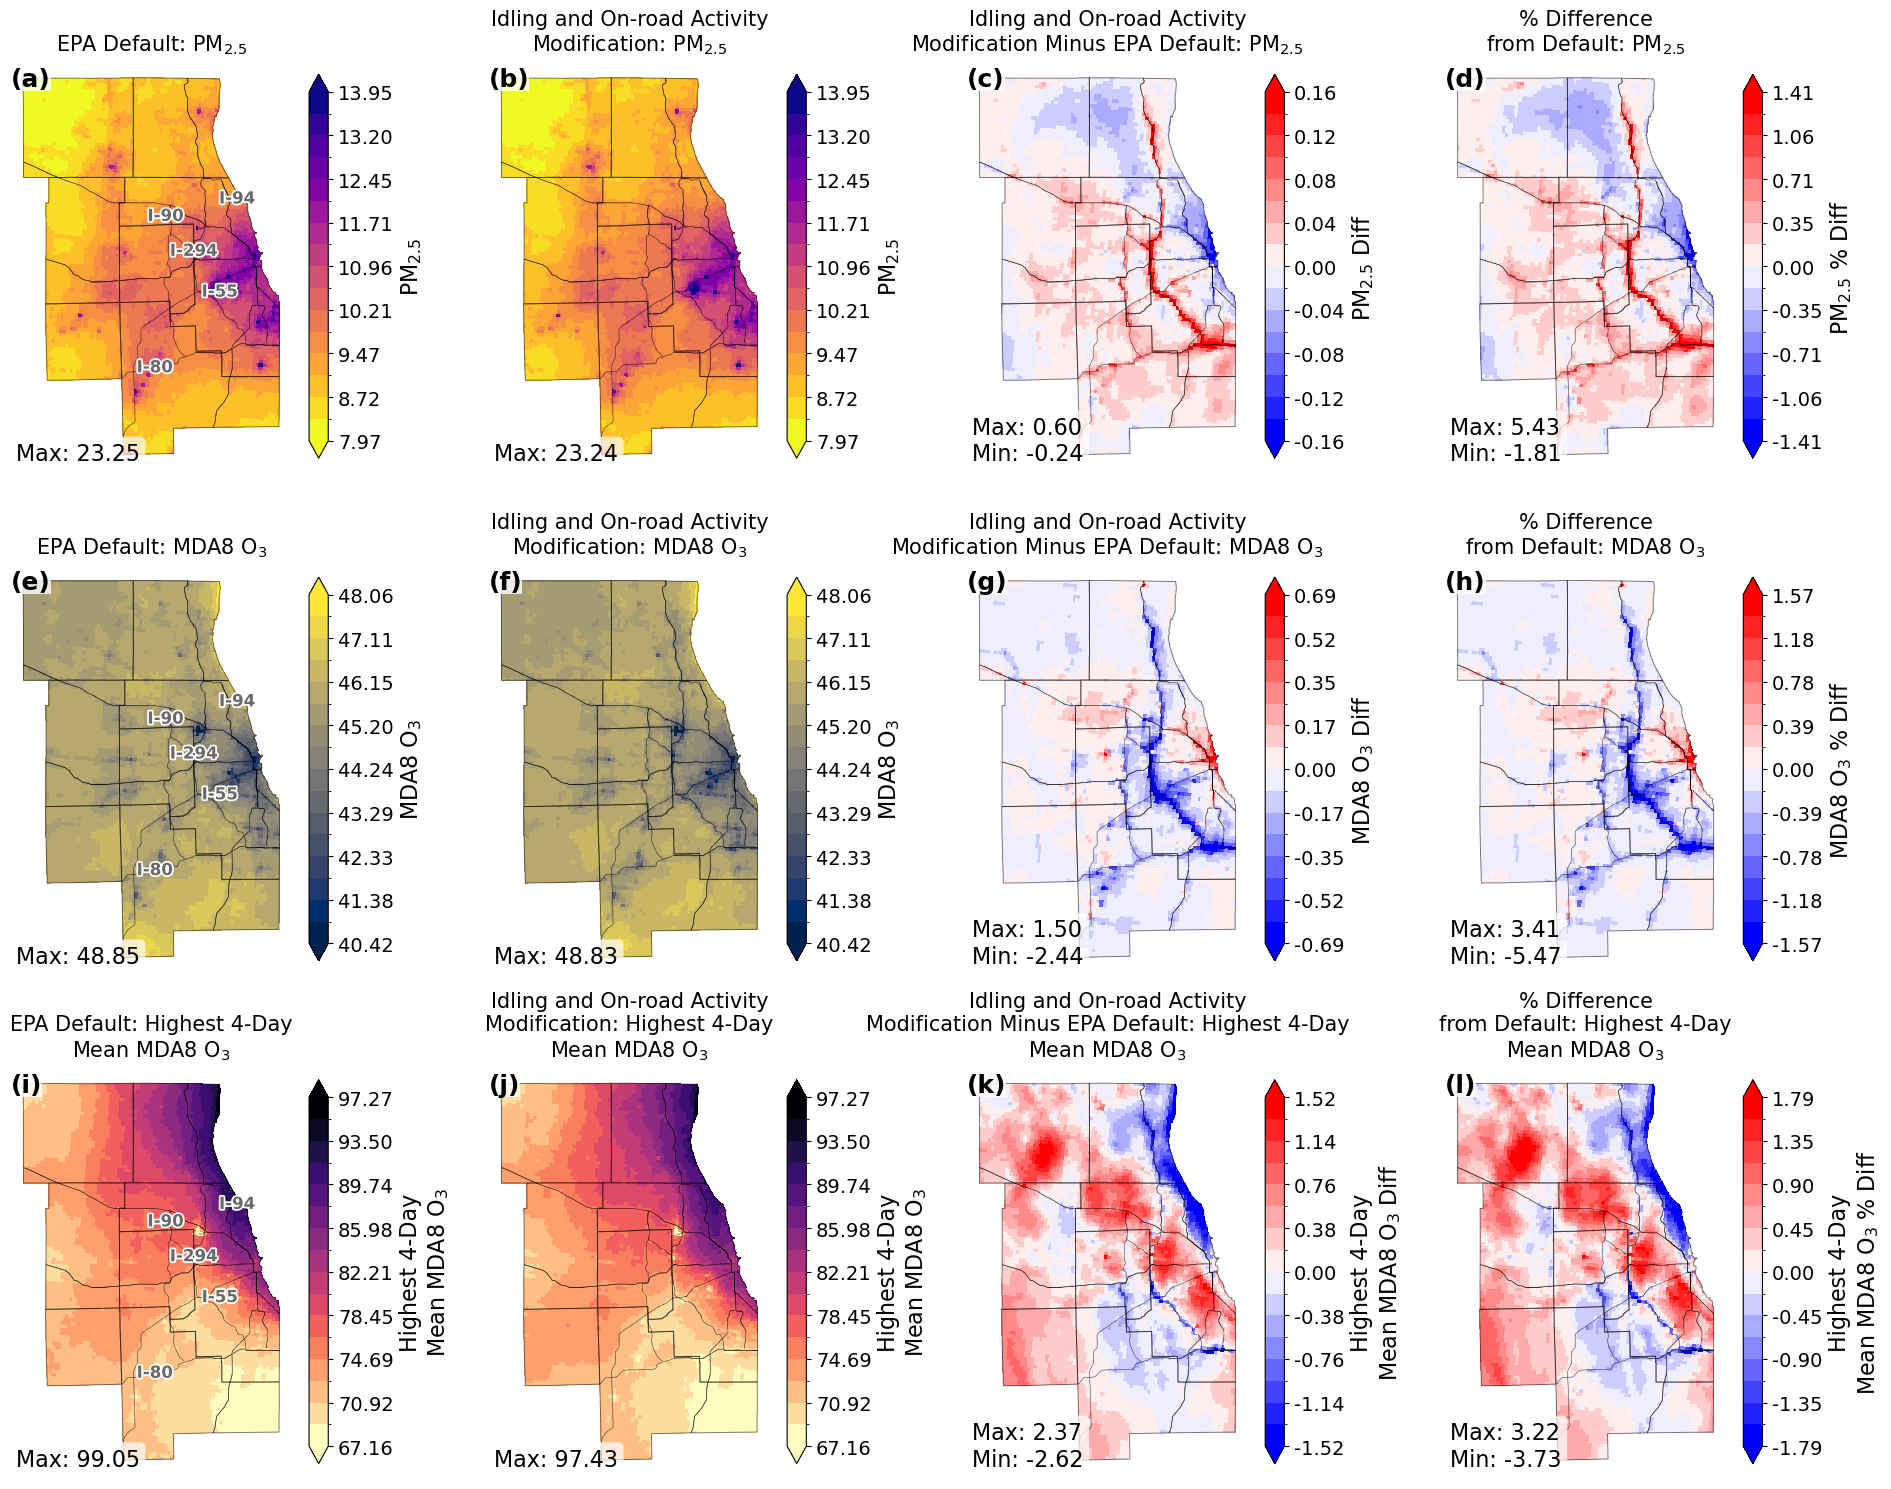

In [41]:
# plotting setup
N_BINS = 16
pollutants = ["PM25_TOT", "O3"]
scenario_names = ["EPA Default", "Idling and On-road Activity\nModification", "Idling and On-road Activity\nModification Minus EPA Default", "% Difference\nfrom Default"]

plot_config = {"PM25_TOT": {"cmap_name": "plasma_r", "title": "PM$_{2.5}$", "label": "PM$_{2.5}$", "column": "PM25_TOT"}, "O3": {"cmap_name": "cividis", "title": "MDA8 O$_3$", "label": "MDA8 O$_3$", "column": "O3"}}
annual_gdfs_by_pol = {"PM25_TOT": {"reference": cmap_base_aconc, "scenario": cmap_locus_aconc}, "O3": {"reference": cmap_base_o3, "scenario": cmap_locus_o3}}


def plot_annual_default_locus_pm25_o3():

    # set shared plotting ranges and colormaps for annual PM2.5 and MDA8 O3
    abs_styles = {}
    diff_styles = {}

    for pol in pollutants:
        cfg = plot_config[pol]
        col = cfg["column"]
        reference_gdf = annual_gdfs_by_pol[pol]["reference"]
        scenario_gdf = annual_gdfs_by_pol[pol]["scenario"]

        # use the same absolute range for EPA Default and the modified activity scenario
        vals_all = np.concatenate([gdf[col].astype(float).to_numpy()[np.isfinite(gdf[col].astype(float).to_numpy())] for gdf in [reference_gdf, scenario_gdf]])
        vmin = np.quantile(vals_all, 0.001)
        vmax = np.quantile(vals_all, 0.999)
        if np.isclose(vmin, vmax): vmax = vmin + 1e-6

        cmap_disc = ListedColormap(plt.cm.get_cmap(cfg["cmap_name"])(np.linspace(0, 1, N_BINS)))
        bounds = np.linspace(vmin, vmax, N_BINS + 1)
        abs_styles[pol] = {"bounds": bounds, "cmap": cmap_disc, "norm": BoundaryNorm(bounds, cmap_disc.N)}

        # calculate absolute and percent changes from EPA Default and center both scales on zero
        reference_vals = reference_gdf[col].astype(float).to_numpy()
        scenario_vals = scenario_gdf[col].astype(float).to_numpy()
        diff_vals = scenario_vals - reference_vals
        pct_vals = np.where(reference_vals != 0, (diff_vals / reference_vals) * 100.0, np.nan)

        diff_lim = np.quantile(np.abs(diff_vals[np.isfinite(diff_vals)]), 0.99)
        pct_lim = np.quantile(np.abs(pct_vals[np.isfinite(pct_vals)]), 0.99)
        if np.isclose(diff_lim, 0): diff_lim = 1e-6
        if np.isclose(pct_lim, 0): pct_lim = 1e-6

        diff_bounds = np.linspace(-diff_lim, diff_lim, N_BINS + 1)
        pct_bounds = np.linspace(-pct_lim, pct_lim, N_BINS + 1)
        diff_cmap = ListedColormap(plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS)))
        pct_cmap = ListedColormap(plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS)))
        diff_styles[pol] = {"diff_bounds": diff_bounds, "diff_cmap": diff_cmap, "diff_norm": BoundaryNorm(diff_bounds, diff_cmap.N), "pct_bounds": pct_bounds, "pct_cmap": pct_cmap, "pct_norm": BoundaryNorm(pct_bounds, pct_cmap.N)}

    # create annual plotting GeoDataFrames for EPA Default, modified activity, absolute difference, and percent difference
    scenario_gdfs_by_pol = {}

    for pol in pollutants:
        col = plot_config[pol]["column"]
        reference_gdf = annual_gdfs_by_pol[pol]["reference"]
        scenario_gdf = annual_gdfs_by_pol[pol]["scenario"]
        ref_vals = reference_gdf[col].astype(float)
        scen_vals = scenario_gdf[col].astype(float)

        plot_reference = reference_gdf.copy()
        plot_scenario = scenario_gdf.copy()
        plot_diff = scenario_gdf.copy()
        plot_pct = scenario_gdf.copy()

        plot_reference[pol] = ref_vals
        plot_scenario[pol] = scen_vals
        plot_diff[pol] = scen_vals - ref_vals
        plot_pct[pol] = np.where(ref_vals != 0, ((scen_vals - ref_vals) / ref_vals) * 100.0, np.nan)
        scenario_gdfs_by_pol[pol] = {scenario_names[0]: plot_reference, scenario_names[1]: plot_scenario, scenario_names[2]: plot_diff, scenario_names[3]: plot_pct}

    # build the four-highest-day MDA8 O3 row
    highest4_reference = cmap_fourhighestdays.copy()
    highest4_scenario = cmap_fourhighestdays.copy()
    highest4_diff = cmap_fourhighestdays.copy()
    highest4_pct = cmap_fourhighestdays.copy()

    highest4_ref_vals = cmap_fourhighestdays["O3_BASE"].astype(float)
    highest4_scen_vals = cmap_fourhighestdays["O3_LOCUS"].astype(float)

    highest4_reference["O3_HIGH4"] = highest4_ref_vals
    highest4_scenario["O3_HIGH4"] = highest4_scen_vals
    highest4_diff["O3_HIGH4"] = highest4_scen_vals - highest4_ref_vals
    highest4_pct["O3_HIGH4"] = np.where(highest4_ref_vals != 0, ((highest4_scen_vals - highest4_ref_vals) / highest4_ref_vals) * 100.0, np.nan)
    highest4_gdfs = {scenario_names[0]: highest4_reference, scenario_names[1]: highest4_scenario, scenario_names[2]: highest4_diff, scenario_names[3]: highest4_pct}

    # use a shared absolute scale for EPA Default and modified activity on the four highest days
    highest4_abs_vals = np.concatenate([highest4_ref_vals.to_numpy(), highest4_scen_vals.to_numpy()])
    highest4_abs_vals = highest4_abs_vals[np.isfinite(highest4_abs_vals)]
    highest4_vmin = np.quantile(highest4_abs_vals, 0.001)
    highest4_vmax = np.quantile(highest4_abs_vals, 0.999)
    if np.isclose(highest4_vmin, highest4_vmax): highest4_vmax = highest4_vmin + 1e-6

    highest4_cmap = ListedColormap(plt.cm.get_cmap("magma_r")(np.linspace(0, 1, N_BINS)))
    highest4_bounds = np.linspace(highest4_vmin, highest4_vmax, N_BINS + 1)
    highest4_norm = BoundaryNorm(highest4_bounds, highest4_cmap.N)

    # set symmetric absolute and percent-difference scales for the four highest days
    highest4_diff_vals = highest4_scen_vals.to_numpy() - highest4_ref_vals.to_numpy()
    highest4_pct_vals = np.where(highest4_ref_vals.to_numpy() != 0, (highest4_diff_vals / highest4_ref_vals.to_numpy()) * 100.0, np.nan)
    highest4_diff_lim = np.quantile(np.abs(highest4_diff_vals[np.isfinite(highest4_diff_vals)]), 0.99)
    highest4_pct_lim = np.quantile(np.abs(highest4_pct_vals[np.isfinite(highest4_pct_vals)]), 0.99)
    if np.isclose(highest4_diff_lim, 0): highest4_diff_lim = 1e-6
    if np.isclose(highest4_pct_lim, 0): highest4_pct_lim = 1e-6

    highest4_diff_bounds = np.linspace(-highest4_diff_lim, highest4_diff_lim, N_BINS + 1)
    highest4_pct_bounds = np.linspace(-highest4_pct_lim, highest4_pct_lim, N_BINS + 1)
    highest4_diff_cmap = ListedColormap(plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS)))
    highest4_pct_cmap = ListedColormap(plt.cm.get_cmap("bwr")(np.linspace(0, 1, N_BINS)))
    highest4_diff_norm = BoundaryNorm(highest4_diff_bounds, highest4_diff_cmap.N)
    highest4_pct_norm = BoundaryNorm(highest4_pct_bounds, highest4_pct_cmap.N)

    # create 3 x 4 figure for annual PM2.5, annual MDA8 O3, and the four highest MDA8 O3 days
    fig, axs = plt.subplots(nrows=3, ncols=4, figsize=(20, 15), subplot_kw={"projection": ccrs.PlateCarree()})

    # plot annual PM2.5 and MDA8 O3
    for i, pol in enumerate(pollutants):
        for j, scen in enumerate(scenario_names):
            ax = axs[i, j]
            gdf = scenario_gdfs_by_pol[pol][scen]
            panel_label = f"({chr(97 + i * 4 + j)})"

            ax.text(0.001, 0.98, panel_label, transform=ax.transAxes, ha="left", va="top", fontsize=18, fontweight="bold", bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=0.2), zorder=10)

            # select absolute, difference, or percent-difference plotting style
            if j in [0, 1]: cmap_disc, norm, bounds = abs_styles[pol]["cmap"], abs_styles[pol]["norm"], abs_styles[pol]["bounds"]
            elif j == 2: cmap_disc, norm, bounds = diff_styles[pol]["diff_cmap"], diff_styles[pol]["diff_norm"], diff_styles[pol]["diff_bounds"]
            else: cmap_disc, norm, bounds = diff_styles[pol]["pct_cmap"], diff_styles[pol]["pct_norm"], diff_styles[pol]["pct_bounds"]

            # plot concentrations and geographic reference layers
            gdf.plot(column=pol, ax=ax, cmap=cmap_disc, norm=norm, edgecolor="none", antialiased=False)
            cmap_cty.boundary.plot(ax=ax, color="k", alpha=0.5, linewidth=0.7)
            cmap_roads.plot(ax=ax, color="k", alpha=0.4, linewidth=0.4)
            if j == 0: add_interstate_labels_manual(ax, fontsize=12)

            ax.set_title(f"{scen}: {plot_config[pol]['title']}", fontsize=15)
            ax.set_axis_off()

            # add panel-specific colorbar
            sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_disc)
            sm._A = []
            cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04, boundaries=bounds, ticks=bounds[::2], spacing="proportional", extend="both")
            cbar.ax.tick_params(labelsize=14)
            cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

            if j == 3: cbar.set_label(f"{plot_config[pol]['label']} % Diff", fontsize=16)
            elif j == 2: cbar.set_label(f"{plot_config[pol]['label']} Diff", fontsize=16)
            else: cbar.set_label(plot_config[pol]["label"], fontsize=16)

            # show the maximum for concentration panels and both extremes for changes
            vals = gdf[pol].astype(float).to_numpy()
            vals = vals[np.isfinite(vals)]
            vmax_panel = float(np.nanmax(vals))
            vmin_panel = float(np.nanmin(vals))
            annot_text = f"Max: {vmax_panel:.2f}" if j in [0, 1] else f"Max: {vmax_panel:.2f}\nMin: {vmin_panel:.2f}"
            ax.text(0.02, 0.02, annot_text, transform=ax.transAxes, ha="left", va="bottom", fontsize=16, color="black", bbox=dict(facecolor="white", alpha=0.7, boxstyle="round,pad=0.25", linewidth=0), zorder=10)

    # plot the four highest MDA8 O3 days in the third row
    i = 2

    for j, scen in enumerate(scenario_names):
        ax = axs[i, j]
        gdf = highest4_gdfs[scen]
        panel_label = f"({chr(97 + i * 4 + j)})"

        ax.text(0.001, 0.98, panel_label, transform=ax.transAxes, ha="left", va="top", fontsize=18, fontweight="bold", bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=0.2), zorder=10)

        # select absolute, difference, or percent-difference plotting style
        if j in [0, 1]: cmap_disc, norm, bounds = highest4_cmap, highest4_norm, highest4_bounds
        elif j == 2: cmap_disc, norm, bounds = highest4_diff_cmap, highest4_diff_norm, highest4_diff_bounds
        else: cmap_disc, norm, bounds = highest4_pct_cmap, highest4_pct_norm, highest4_pct_bounds

        # plot four-highest-day MDA8 O3 and geographic reference layers
        gdf.plot(column="O3_HIGH4", ax=ax, cmap=cmap_disc, norm=norm, edgecolor="none", antialiased=False)
        cmap_cty.boundary.plot(ax=ax, color="k", alpha=0.5, linewidth=0.7)
        cmap_roads.plot(ax=ax, color="k", alpha=0.4, linewidth=0.4)
        if j == 0: add_interstate_labels_manual(ax, fontsize=12)

        ax.set_title(f"{scen}: Highest 4-Day\nMean MDA8 O$_3$", fontsize=15)
        ax.set_axis_off()

        # add panel-specific colorbar
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_disc)
        sm._A = []
        cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04, boundaries=bounds, ticks=bounds[::2], spacing="proportional", extend="both")
        cbar.ax.tick_params(labelsize=14)
        cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

        if j == 3: cbar.set_label("Highest 4-Day\nMean MDA8 O$_3$ % Diff", fontsize=16)
        elif j == 2: cbar.set_label("Highest 4-Day\nMean MDA8 O$_3$ Diff", fontsize=16)
        else: cbar.set_label("Highest 4-Day\nMean MDA8 O$_3$", fontsize=16)

        # show the maximum for absolute concentrations and both extremes for changes
        vals = gdf["O3_HIGH4"].astype(float).to_numpy()
        vals = vals[np.isfinite(vals)]
        vmax_panel = float(np.nanmax(vals))
        vmin_panel = float(np.nanmin(vals))
        annot_text = f"Max: {vmax_panel:.2f}" if j in [0, 1] else f"Max: {vmax_panel:.2f}\nMin: {vmin_panel:.2f}"
        ax.text(0.02, 0.02, annot_text, transform=ax.transAxes, ha="left", va="bottom", fontsize=16, color="black", bbox=dict(facecolor="white", alpha=0.7, boxstyle="round,pad=0.25", linewidth=0), zorder=10)

    # finish layout and save as both PNG and PDF
    plt.tight_layout()
    plt.savefig("Fig_SI_Annualized_Default_MOD_PM25_MDA8O3_High4_2023.png", dpi=500, bbox_inches="tight")
    plt.savefig("Fig_SI_Annualized_Default_MOD_PM25_MDA8O3_High4_2023.pdf", dpi=500, bbox_inches="tight")
    plt.show()


plot_annual_default_locus_pm25_o3()